In [1]:
import yfinance as yf
print("Installed successfully ✅")

Installed successfully ✅


In [2]:
import yfinance as yf
import pandas as pd

# Stock choose karo (TCS example)
stock = "TCS.NS"

# Data download
data = yf.download(stock, start="2020-01-01", end="2024-01-01")

# Show first 5 rows
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1866.113892,1880.146596,1854.405398,1866.458173,1354908
2020-01-02,1857.547607,1876.745997,1850.272939,1876.745997,2380752
2020-01-03,1894.566895,1913.808372,1863.014537,1863.014537,4655761
2020-01-06,1894.395142,1916.348414,1883.590646,1898.312336,3023209
2020-01-07,1899.043823,1906.619685,1880.060662,1894.437858,2429317


In [4]:
import os

os.makedirs("../data", exist_ok=True)
data.to_csv("../data/tcs_data.csv")

In [5]:
data.to_csv("tcs_data.csv")

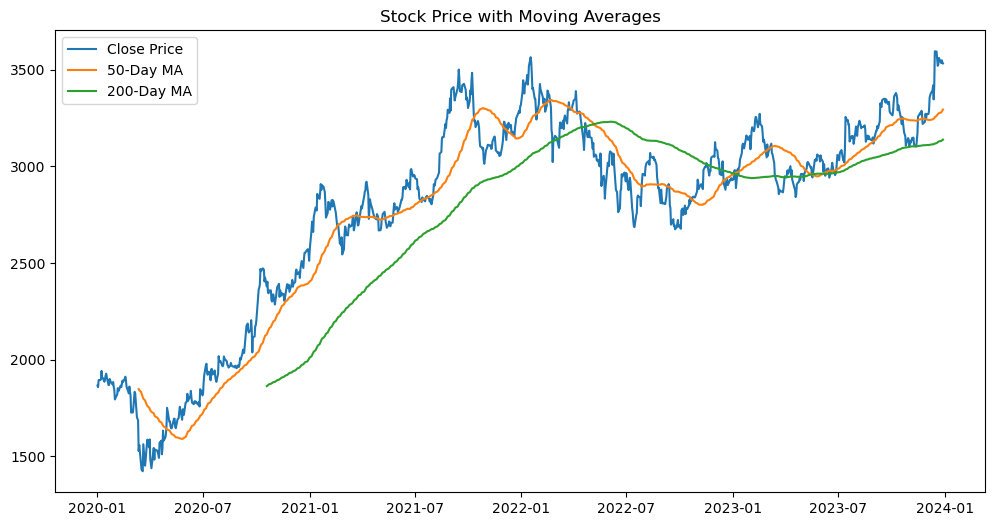

In [6]:
import matplotlib.pyplot as plt

# Moving Average
data['MA50'] = data['Close'].rolling(50).mean()
data['MA200'] = data['Close'].rolling(200).mean()

# Plot
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50-Day MA')
plt.plot(data['MA200'], label='200-Day MA')

plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()

In [7]:
data[['Close','MA50','MA200']].tail()

Price,Close,MA50,MA200
Ticker,TCS.NS,,
Date,,,
2023-12-22,3561.376953,3275.743872,3129.500228
2023-12-26,3534.880859,3279.375400,3131.605997
2023-12-27,3549.456299,3284.549683,3134.080090
2023-12-28,3538.932129,3288.987720,3136.406376
2023-12-29,3532.878662,3294.174165,3138.565822


In [8]:
# Sirf Close price use karenge
df = data[['Close']].copy()

# Next day prediction ke liye target
df['Target'] = df['Close'].shift(-1)

# Last row me NaN aayega → remove
df.dropna(inplace=True)

df.head()

Price,Close,Target
Ticker,TCS.NS,
Date,,
2020-01-01,1866.113892,1857.547607
2020-01-02,1857.547607,1894.566895
2020-01-03,1894.566895,1894.395142
2020-01-06,1894.395142,1899.043823
2020-01-07,1899.043823,1941.572632


In [9]:
from sklearn.model_selection import train_test_split

X = df[['Close']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [11]:
predictions = model.predict(X_test)

print(predictions[:5])

[2379.43356755 2672.59431632 3424.79769777 2698.69682592 1700.92814139]


In [12]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 1618.693952988449


In [14]:
latest_price = df[['Close']].iloc[-1:]
predicted_price = model.predict(latest_price)

print("Next day predicted price:", predicted_price[0])

Next day predicted price: 3538.6424133204346


In [17]:
import os
import pickle

# folder create
os.makedirs("../model", exist_ok=True)

# save model
with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved ✅")

Model saved ✅


In [18]:
with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [19]:
import pickle

with open("model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved ✅")

Model saved ✅
